
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%205%20Probabilistic%20Classification/05-ProbClass.ipynb)

# Probabilistic Classification
## Logistic Regression, Naive Bayes, and the Cost of Being Confidently Wrong

A mushroom classifier can make two kinds of mistakes: discard an edible mushroom or recommend a poisonous one. That asymmetry makes this a useful case study for a larger question: **how should a model turn uncertain evidence into a decision?**

Our path is: **score → probability → model → probability audit → decision threshold**. By the end, you should be able to distinguish discriminative from generative classification, interpret predicted probabilities, test a modeling assumption, and choose a threshold from the costs of errors.

> 🍄 **This notebook is not a foraging license.** A predicted probability—even `0.0001`—does not turn a mystery mushroom into lunch. These are classroom data; never use these models or rules to decide whether a real mushroom is edible.

## Part 1: From an Unbounded Score to a Probability

A line is a natural first attempt at binary prediction. Inspect the left panel before reading the equation below: what prevents its output from being a probability?

In [21]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyBboxPatch
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

plot_style = next(
    (name for name in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid")
     if name in plt.style.available),
    "default",
)
plt.style.use(plot_style)

COLORS = {
    "edible": "#2A9D8F",
    "poison": "#E76F51",
    "logistic": "#3A86FF",
    "bayes": "#F4A261",
    "ink": "#263238",
    "muted": "#8D99AE",
}

FEATURES = [
    "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
    "ring-type", "spore-print-color", "population", "habitat",
]

CATEGORY_NAMES = {
    "odor": {
        "a": "almond", "l": "anise", "c": "creosote", "f": "foul",
        "m": "musty", "n": "none", "p": "pungent", "s": "spicy",
        "y": "fishy",
    },
    "cap-color": {
        "n": "brown", "b": "buff", "c": "cinnamon", "g": "gray",
        "r": "green", "p": "pink", "u": "purple", "e": "red",
        "w": "white", "y": "yellow",
    },
    "habitat": {
        "g": "grasses", "l": "leaves", "m": "meadows", "p": "paths",
        "u": "urban", "w": "waste", "d": "woods",
    },
    "gill-size": {"b": "broad", "n": "narrow"},
    "bruises": {"t": "yes", "f": "no"},
    "ring-type": {
        "c": "cobwebby", "e": "evanescent", "f": "flaring", "l": "large",
        "n": "none", "p": "pendant", "s": "sheathing", "z": "zone",
    },
    "stalk-root": {
        "b": "bulbous", "c": "club", "u": "cup", "e": "equal",
        "z": "rhizomorphs", "r": "rooted", "(unknown)": "unknown",
    },
    "stalk-surface-above-ring": {
        "f": "fibrous", "y": "scaly", "k": "silky", "s": "smooth",
    },
    "stalk-surface-below-ring": {
        "f": "fibrous", "y": "scaly", "k": "silky", "s": "smooth",
    },
    "spore-print-color": {
        "k": "black", "n": "brown", "b": "buff", "h": "chocolate",
        "r": "green", "o": "orange", "u": "purple", "w": "white",
        "y": "yellow",
    },
    "gill-color": {
        "k": "black", "n": "brown", "b": "buff", "h": "chocolate",
        "g": "gray", "r": "green", "o": "orange", "p": "pink",
        "u": "purple", "e": "red", "w": "white", "y": "yellow",
    },
    "population": {
        "a": "abundant", "c": "clustered", "n": "numerous",
        "s": "scattered", "v": "several", "y": "solitary",
    },
}

local_candidates = [
    Path("mushroom/agaricus-lepiota.data"),
    Path("Lecture 5 Probabilistic Classification/mushroom/agaricus-lepiota.data"),
]
data_source = next((path for path in local_candidates if path.exists()), None)
if data_source is None:
    data_source = (
        "https://raw.githubusercontent.com/jinming99/learn-ml-by-building/"
        "main/Lecture%205%20Probabilistic%20Classification/mushroom/"
        "agaricus-lepiota.data"
    )

df = pd.read_csv(data_source, header=None, names=["class"] + FEATURES, dtype=str)
df["poisonous"] = (df["class"] == "p").astype(int)
X = df[FEATURES].replace("?", "(unknown)")
y = df["poisonous"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


def style_axes(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.22)
    ax.spines[["top", "right"]].set_visible(False)


def pretty_category(feature, value):
    return CATEGORY_NAMES.get(feature, {}).get(value, value)


def draw_record_card(ax, left, case, color, title, row):
    """Draw only fields that are present in one held-out data record."""
    card = FancyBboxPatch(
        (left, 0.06), 0.235, 0.86,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        linewidth=1.1, edgecolor=color, facecolor="white", alpha=0.98,
    )
    ax.add_patch(card)
    ax.text(left + 0.018, 0.82, "HELD-OUT RECORD", fontsize=7.2,
            color=color, va="center", fontweight="bold")
    ax.text(left + 0.018, 0.67, f"{case} · {title}", fontsize=9.2,
            fontweight="bold", color=COLORS["ink"], va="center")
    ax.text(
        left + 0.018, 0.38,
        f"Actually {'poisonous' if row['truth'] else 'edible'}\n"
        f"odor: {pretty_category('odor', row['odor'])}  ·  "
        f"spores: {pretty_category('spore-print-color', row['spore-print-color'])}\n"
        f"habitat: {pretty_category('habitat', row['habitat'])}",
        fontsize=8.2, color=COLORS["ink"], va="center", linespacing=1.35,
    )

/var/folders/mk/nj20_4tx79s1r5t47zmf164c0000gn/T/ipykernel_65444/1479623307.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0, 1, 0.96))


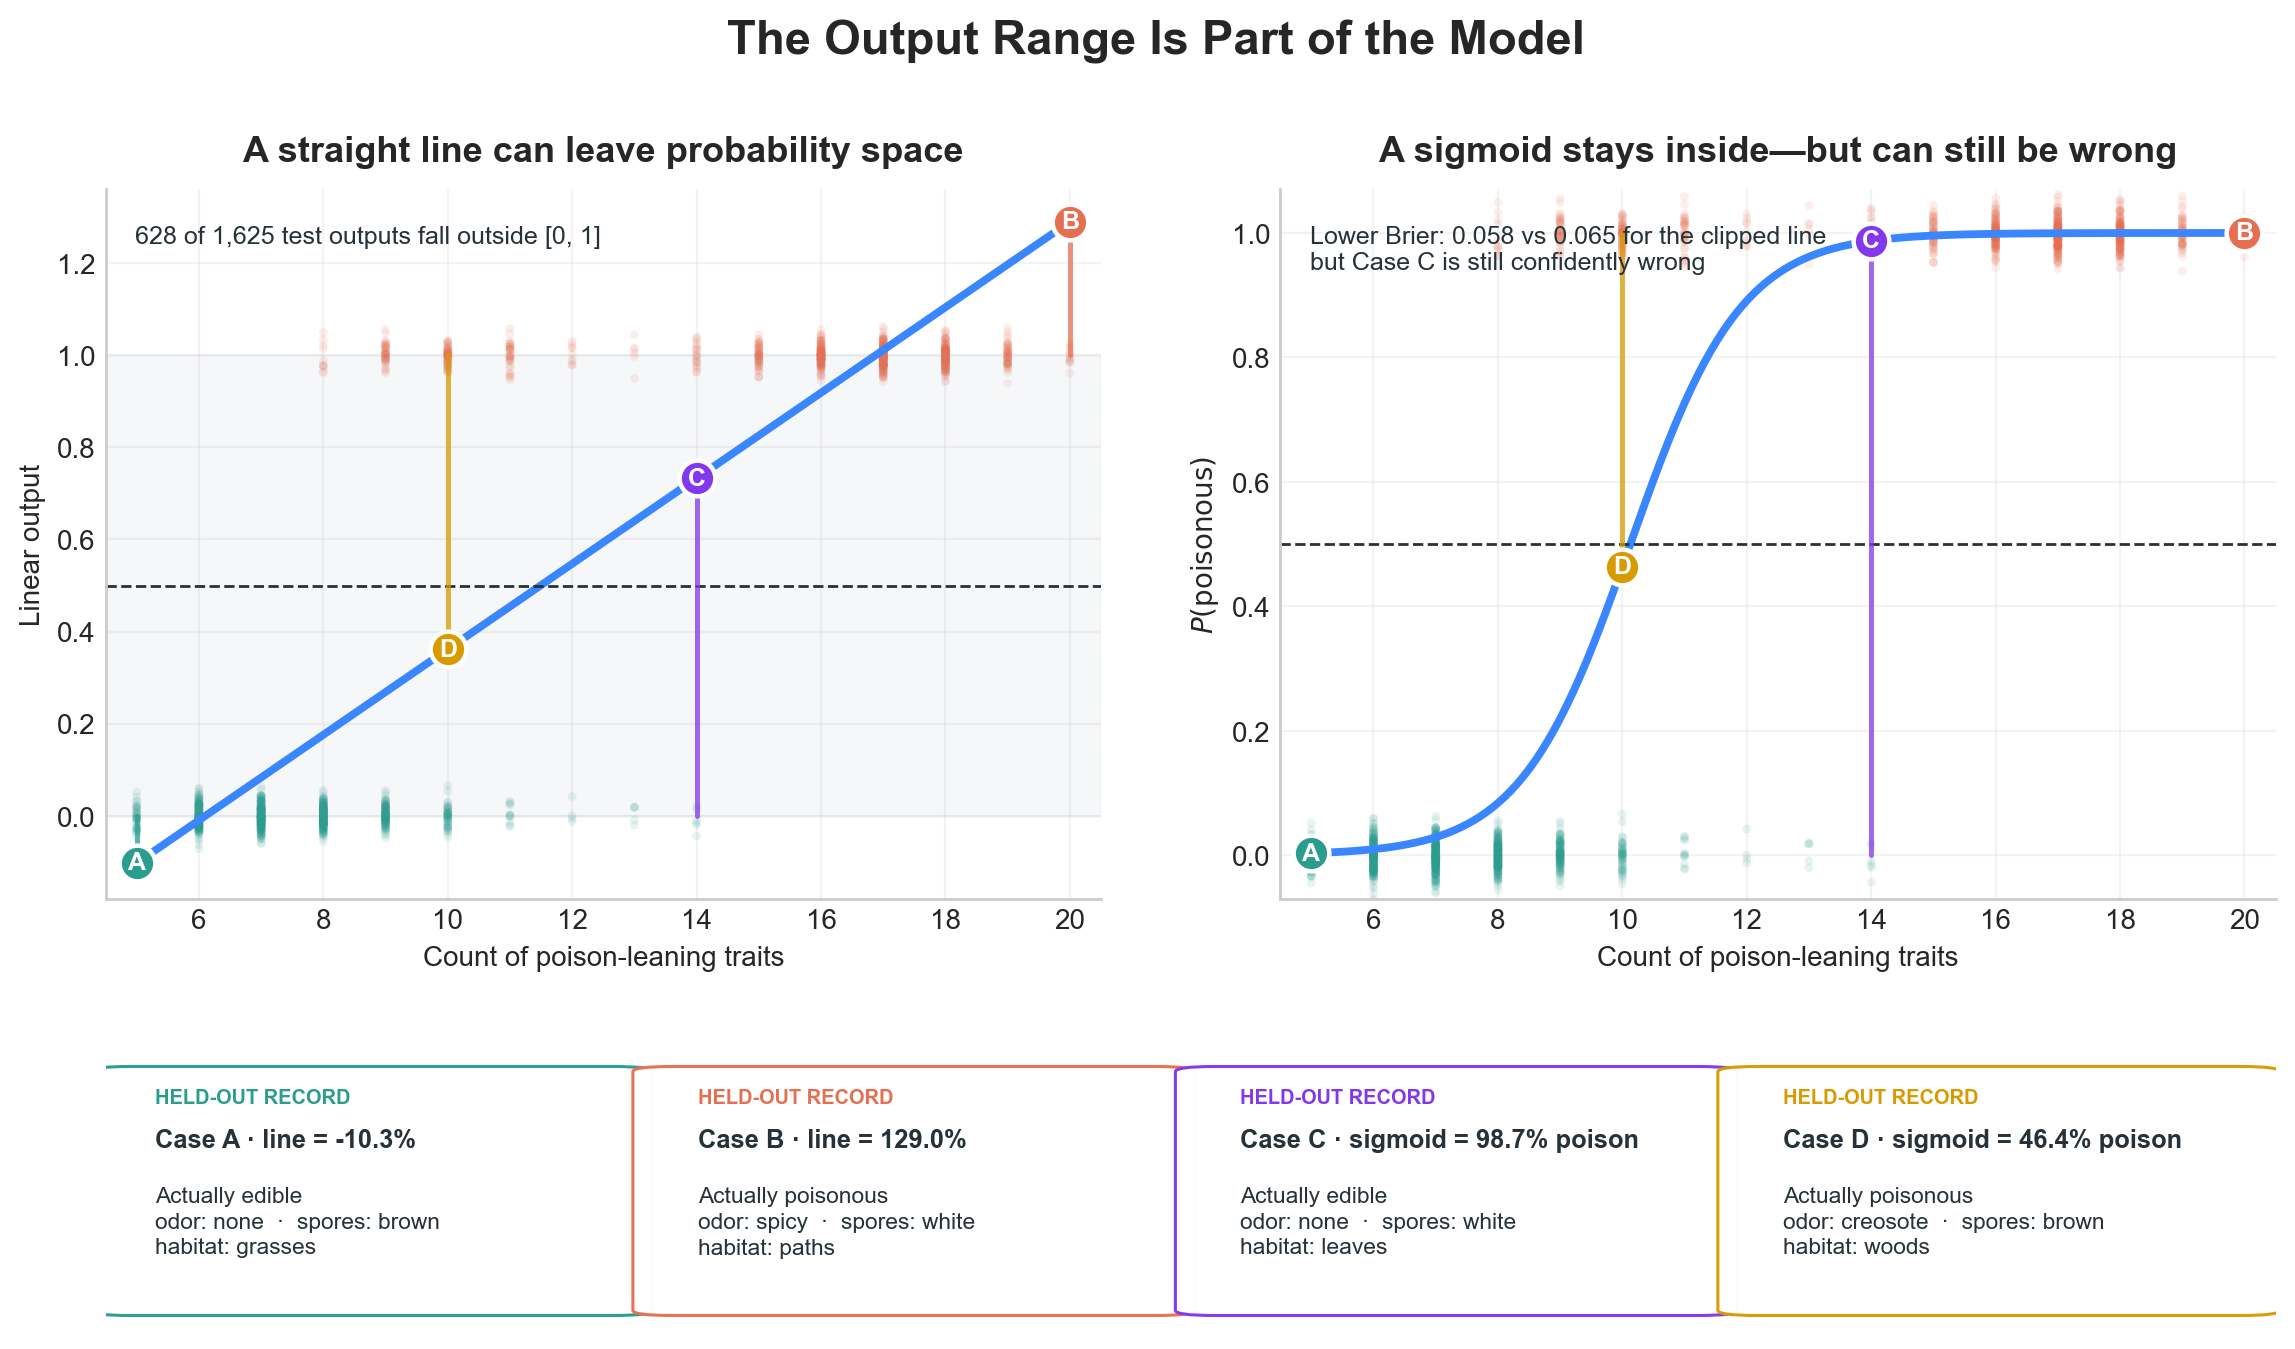

In [22]:
# Give every categorical record one interpretable coordinate: how many of its
# observed categories lean more poisonous than the training-set base rate?
training_base_rate = y_train.mean()
category_risk_maps = {
    feature: y_train.groupby(X_train[feature]).mean()
    for feature in FEATURES
}


def poison_evidence_count(frame):
    indicators = [
        frame[feature].map(category_risk_maps[feature]).gt(training_base_rate)
        for feature in FEATURES
    ]
    return np.column_stack(indicators).sum(axis=1)


train_score = poison_evidence_count(X_train)
test_score = poison_evidence_count(X_test)
score_linear_model = LinearRegression().fit(train_score[:, None], y_train)
score_logistic_model = LogisticRegression().fit(train_score[:, None], y_train)
linear_test_output = score_linear_model.predict(test_score[:, None])
logistic_test_probability = score_logistic_model.predict_proba(test_score[:, None])[:, 1]

edible_positions = np.flatnonzero(y_test.to_numpy() == 0)
poison_positions = np.flatnonzero(y_test.to_numpy() == 1)
case_positions = [
    int(np.argmin(linear_test_output)),
    int(np.argmax(linear_test_output)),
    int(edible_positions[np.argmax(logistic_test_probability[edible_positions])]),
    int(poison_positions[np.argmin(np.abs(logistic_test_probability[poison_positions] - 0.5))]),
]
case_frame = X_test.iloc[case_positions][
    ["odor", "spore-print-color", "habitat"]
].reset_index(drop=True)
case_frame["truth"] = y_test.iloc[case_positions].to_numpy()
case_frame["score"] = test_score[case_positions]
case_frame["linear"] = linear_test_output[case_positions]
case_frame["logistic"] = logistic_test_probability[case_positions]
case_frame["case"] = list("ABCD")
case_frame["title"] = [
    f"line = {case_frame.loc[0, 'linear']:.1%}",
    f"line = {case_frame.loc[1, 'linear']:.1%}",
    f"sigmoid = {case_frame.loc[2, 'logistic']:.1%} poison",
    f"sigmoid = {case_frame.loc[3, 'logistic']:.1%} poison",
]
case_frame["color"] = ["#2A9D8F", "#E76F51", "#8338EC", "#D99A00"]

score_grid = np.linspace(train_score.min(), train_score.max(), 300)
linear_grid_output = score_linear_model.predict(score_grid[:, None])
logistic_grid_probability = score_logistic_model.predict_proba(score_grid[:, None])[:, 1]
out_of_range = ((linear_test_output < 0) | (linear_test_output > 1)).sum()
linear_brier = brier_score_loss(y_test, np.clip(linear_test_output, 0, 1))
score_logistic_brier = brier_score_loss(y_test, logistic_test_probability)
outcome_jitter = np.random.default_rng(7).normal(0, 0.022, len(y_test))
outcome_colors = np.where(y_test.to_numpy(), COLORS["poison"], COLORS["edible"])

fig = plt.figure(figsize=(14, 7.4))
grid = fig.add_gridspec(2, 2, height_ratios=[3.4, 1.35], hspace=0.30, wspace=0.18)
axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])]
specimen_ax = fig.add_subplot(grid[1, :])

for ax, output, curve, panel_title, ylabel in [
    (axes[0], linear_test_output, linear_grid_output,
     "A straight line can leave probability space", "Linear output"),
    (axes[1], logistic_test_probability, logistic_grid_probability,
     "A sigmoid stays inside—but can still be wrong", r"$P(\mathrm{poisonous})$"),
]:
    ax.scatter(test_score, y_test.to_numpy() + outcome_jitter,
               c=outcome_colors, s=10, alpha=0.11, linewidth=0, rasterized=True)
    ax.plot(score_grid, curve, color=COLORS["logistic"], linewidth=2.8, zorder=2)
    ax.axhline(0.5, color=COLORS["ink"], linestyle="--", linewidth=1)
    for _, case in case_frame.iterrows():
        prediction = case["linear"] if ax is axes[0] else case["logistic"]
        ax.plot([case["score"], case["score"]], [case["truth"], prediction],
                color=case["color"], linewidth=1.8, alpha=0.75, zorder=3)
        ax.scatter(case["score"], prediction, s=165, color=case["color"],
                   edgecolor="white", linewidth=1.6, zorder=4)
        ax.text(case["score"], prediction, case["case"], ha="center", va="center",
                color="white", fontsize=9, fontweight="bold", zorder=5)
    style_axes(ax, panel_title, "Count of poison-leaning traits", ylabel)
    ax.set_xlim(train_score.min() - 0.5, train_score.max() + 0.5)

axes[0].axhspan(0, 1, color=COLORS["muted"], alpha=0.08)
axes[0].set_ylim(-0.18, 1.36)
axes[0].text(
    0.03, 0.95,
    f"{out_of_range:,} of {len(y_test):,} test outputs fall outside [0, 1]",
    transform=axes[0].transAxes, va="top", fontsize=9, color=COLORS["ink"],
)
axes[1].set_ylim(-0.07, 1.07)
axes[1].text(
    0.03, 0.95,
    f"Lower Brier: {score_logistic_brier:.3f} vs {linear_brier:.3f} for the clipped line\n"
    "but Case C is still confidently wrong",
    transform=axes[1].transAxes, va="top", fontsize=9, color=COLORS["ink"],
)

specimen_ax.set_xlim(0, 1)
specimen_ax.set_ylim(0, 1)
specimen_ax.axis("off")
for left, (_, case) in zip([0.005, 0.255, 0.505, 0.755], case_frame.iterrows()):
    draw_record_card(
        specimen_ax, left, f"Case {case['case']}", case["color"], case["title"], case
    )

fig.suptitle("The Output Range Is Part of the Model", fontsize=17,
             fontweight="bold", y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

Logistic regression keeps the linear score but changes its interpretation:

$$z=\mathbf{w}^{\mathsf T}\mathbf{x}+b,
\qquad P(y=1\mid\mathbf{x})=\sigma(z)=\frac{1}{1+e^{-z}}.$$

Each faint dot above is a held-out categorical record—not a photographed or identified specimen. The horizontal coordinate is a deliberately simple summary: the number of observed categories whose poison rate exceeds the training-set base rate. The four record snippets show why valid output range and correct probability are different requirements.

The score $z$ is unrestricted evidence; the sigmoid maps it to $[0,1]$. Training uses the same gradient-based machinery as Lecture 4, but with cross-entropy rather than mean squared error. For one observation, cross-entropy is simply $-\log(p_{\text{true}})$.

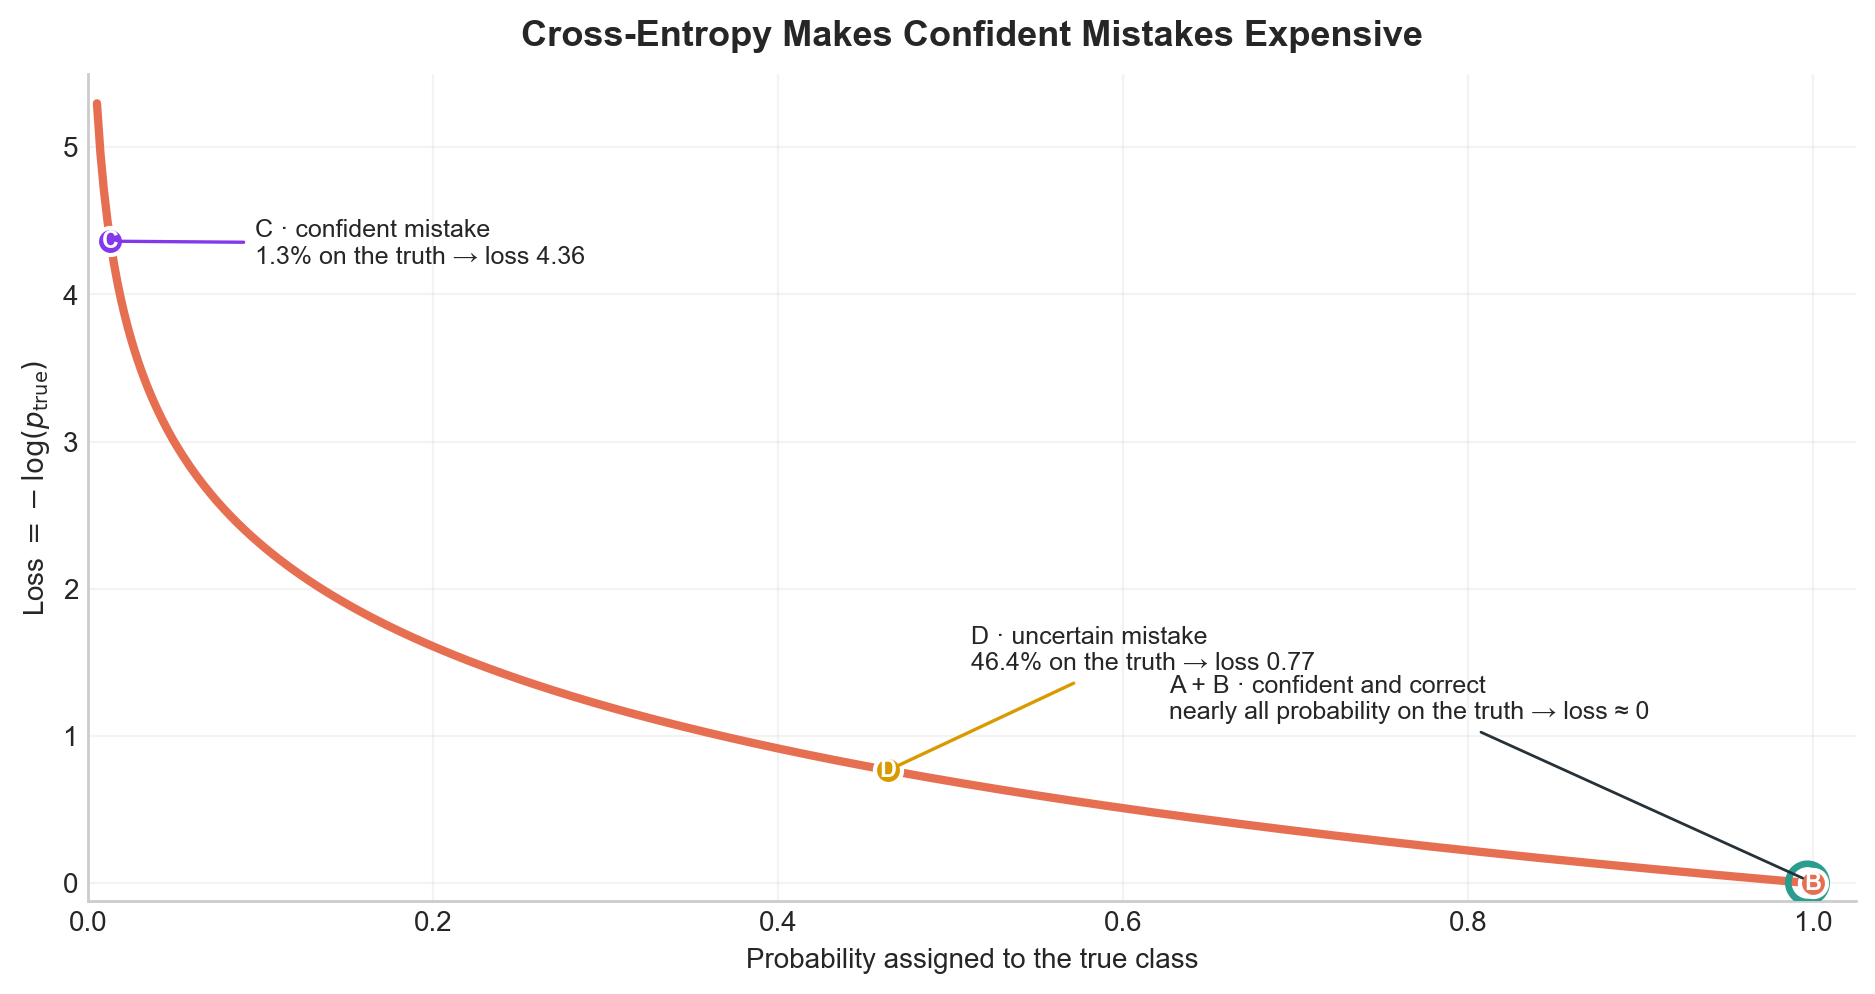

In [23]:
p_true = np.linspace(0.005, 1.0, 500)
loss = -np.log(p_true)

case_frame["p_true"] = np.where(
    case_frame["truth"] == 1,
    case_frame["logistic"],
    1 - case_frame["logistic"],
)
case_frame["cross_entropy"] = -np.log(case_frame["p_true"])

fig, ax = plt.subplots(figsize=(9.5, 5.1))
ax.plot(p_true, loss, color=COLORS["poison"], linewidth=3)
for _, case in case_frame.iterrows():
    is_case_a = case["case"] == "A"
    ax.scatter(
        case["p_true"], case["cross_entropy"],
        s=190 if is_case_a else 95,
        facecolor="none" if is_case_a else case["color"],
        edgecolor=case["color"] if is_case_a else "white",
        linewidth=2.4 if is_case_a else 1.5,
        zorder=3,
    )
    if not is_case_a:
        ax.text(case["p_true"], case["cross_entropy"], case["case"],
                ha="center", va="center", color="white", fontsize=8.5,
                fontweight="bold", zorder=4)

case_c = case_frame.set_index("case").loc["C"]
case_d = case_frame.set_index("case").loc["D"]
ax.annotate(
    f"C · confident mistake\n{case_c['p_true']:.1%} on the truth → loss {case_c['cross_entropy']:.2f}",
    (case_c["p_true"], case_c["cross_entropy"]),
    xytext=(52, -8), textcoords="offset points", fontsize=9,
    arrowprops={"arrowstyle": "-", "color": case_c["color"], "linewidth": 1.2},
)
ax.annotate(
    f"D · uncertain mistake\n{case_d['p_true']:.1%} on the truth → loss {case_d['cross_entropy']:.2f}",
    (case_d["p_true"], case_d["cross_entropy"]),
    xytext=(30, 36), textcoords="offset points", fontsize=9,
    arrowprops={"arrowstyle": "-", "color": case_d["color"], "linewidth": 1.2},
)
ax.annotate(
    "A + B · confident and correct\nnearly all probability on the truth → loss ≈ 0",
    (0.997, 0.02), xytext=(-230, 58), textcoords="offset points", fontsize=9,
    arrowprops={"arrowstyle": "-", "color": COLORS["ink"], "linewidth": 1.0},
)
style_axes(
    ax,
    "Cross-Entropy Makes Confident Mistakes Expensive",
    "Probability assigned to the true class",
    r"Loss $=-\log(p_{\mathrm{true}})$",
)
ax.set_xlim(0, 1.025)
ax.set_ylim(-0.12, 5.5)
ax.set_yticks(np.arange(0, 6))
plt.tight_layout()
plt.show()

## Part 2: What Evidence Does the Dataset Contain?

The UCI Mushroom data describe 8,124 hypothetical mushroom samples using 22 categorical attributes. We will treat `?` as an explicit unknown category rather than silently claiming that the data are complete.

Samples,Categorical features,Poisonous,Unknown stalk-root values
"8,124",22,48.2%,"2,480"


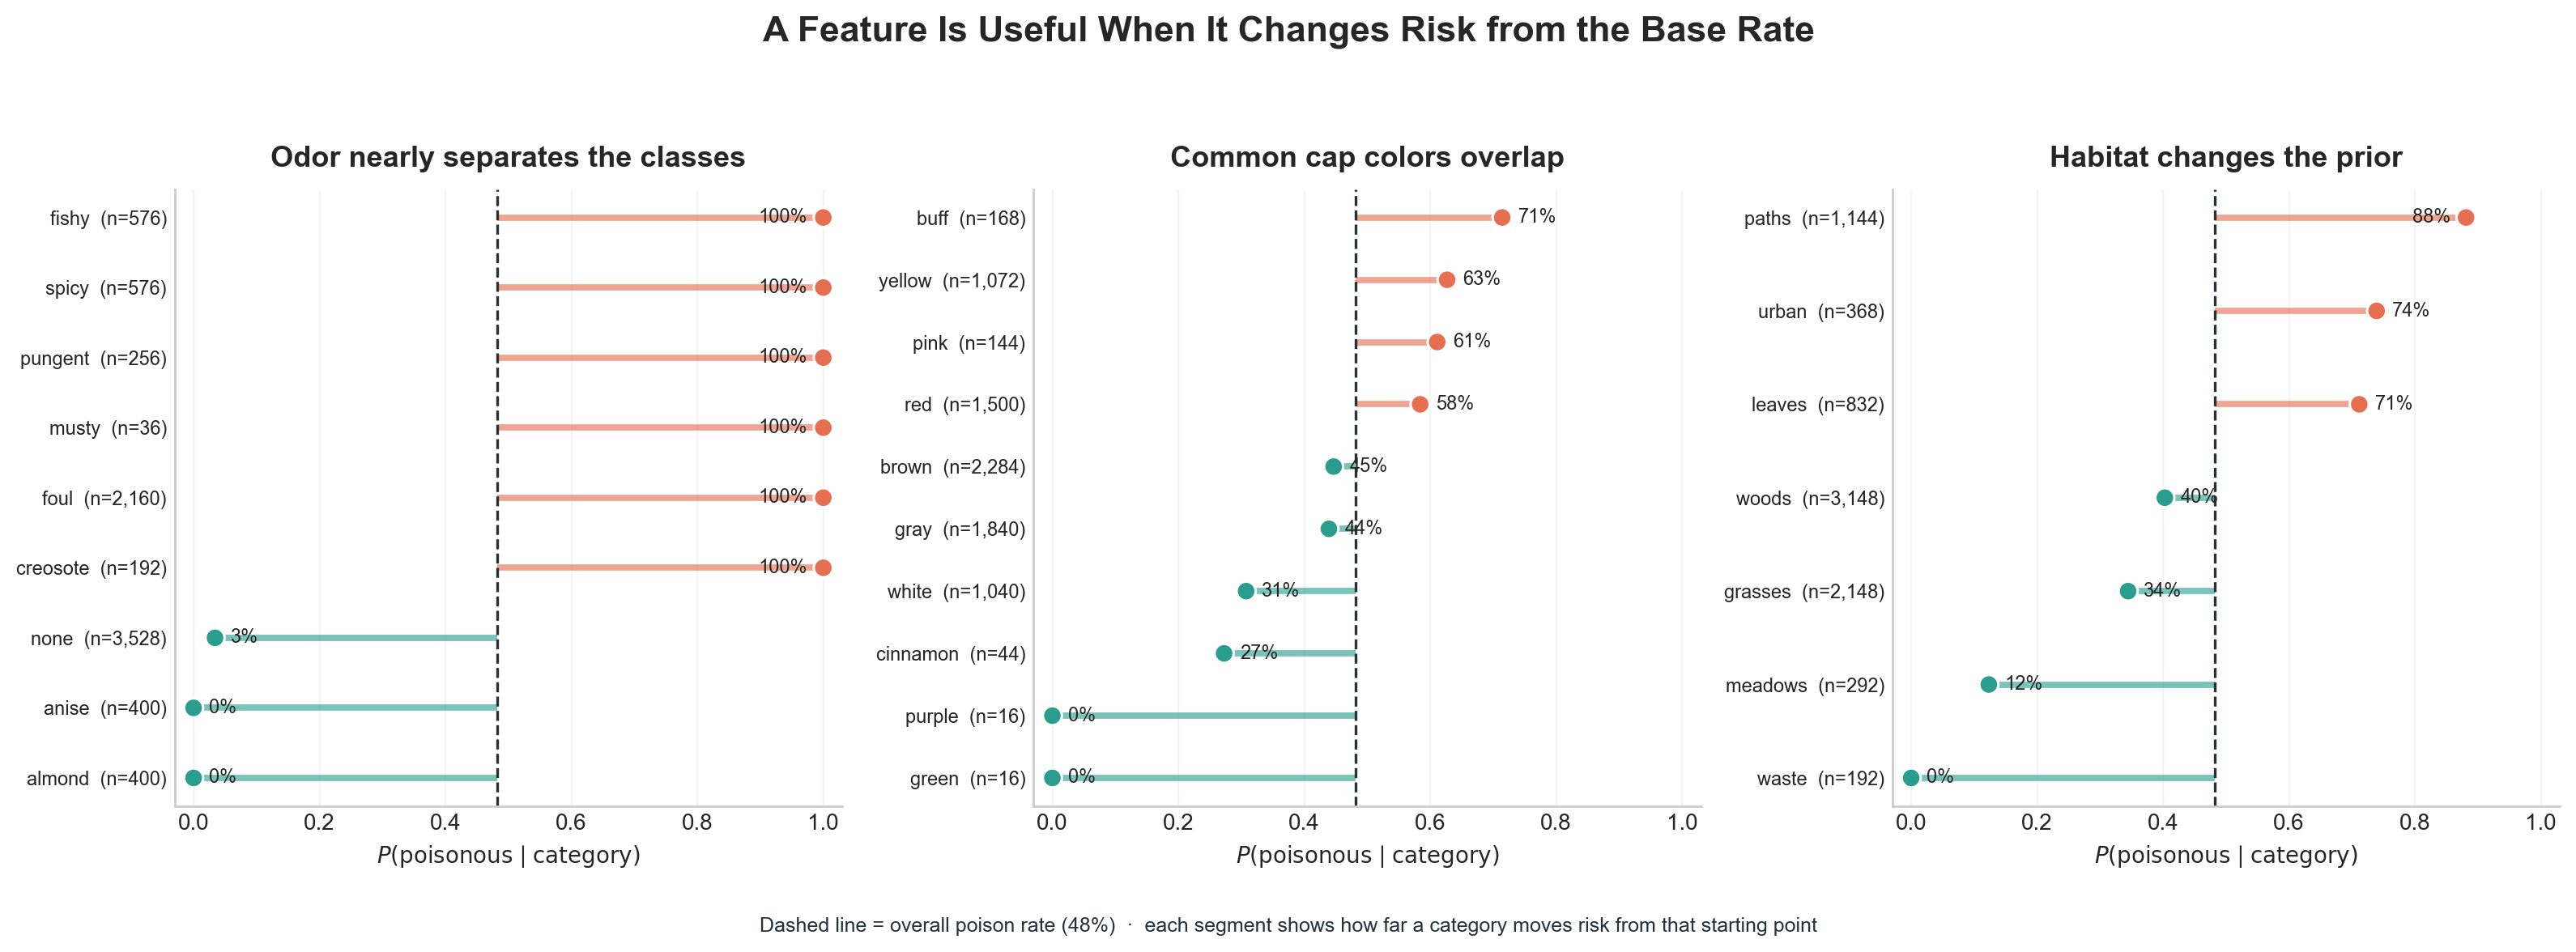

In [24]:
dataset_summary = pd.DataFrame({
    "Samples": [f"{len(df):,}"],
    "Categorical features": [len(FEATURES)],
    "Poisonous": [f"{y.mean():.1%}"],
    "Unknown stalk-root values": [f"{(df['stalk-root'] == '?').sum():,}"],
})
display(dataset_summary.style.hide(axis="index"))


def category_risk(feature):
    summary = (
        df.groupby(feature)["poisonous"]
        .agg(risk="mean", count="size")
        .sort_values("risk")
        .reset_index()
    )
    summary["label"] = summary.apply(
        lambda row: (
            f"{CATEGORY_NAMES[feature].get(row[feature], row[feature])}  "
            f"(n={row['count']:,})"
        ),
        axis=1,
    )
    return summary


feature_panels = [
    ("odor", "Odor nearly separates the classes"),
    ("cap-color", "Common cap colors overlap"),
    ("habitat", "Habitat changes the prior"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.8), sharex=True)
overall_risk = y.mean()
for ax, (feature, title) in zip(axes, feature_panels):
    summary = category_risk(feature)
    y_positions = np.arange(len(summary))
    risk_colors = [
        (COLORS["edible"] if risk < overall_risk else COLORS["poison"])
        for risk in summary["risk"]
    ]
    ax.hlines(y_positions, overall_risk, summary["risk"],
              color=risk_colors, linewidth=2.8, alpha=0.62)
    ax.scatter(summary["risk"], y_positions, color=risk_colors, s=72,
               edgecolor="white", linewidth=1.1, zorder=3)
    ax.axvline(overall_risk, color=COLORS["ink"], linestyle="--", linewidth=1.2)
    for y_position, risk in zip(y_positions, summary["risk"]):
        ax.text(
            risk - 0.025 if risk > 0.88 else risk + 0.025,
            y_position,
            f"{risk:.0%}",
            va="center",
            ha="right" if risk > 0.88 else "left",
            fontsize=8.5,
        )
    ax.set_yticks(y_positions, summary["label"])
    style_axes(ax, title, r"$P(\mathrm{poisonous}\mid\mathrm{category})$")
    ax.set_xlim(-0.03, 1.03)
    ax.tick_params(axis="y", labelsize=8.5)
    ax.grid(axis="y", visible=False)

fig.suptitle("A Feature Is Useful When It Changes Risk from the Base Rate",
             fontsize=16, fontweight="bold", y=0.99)
fig.text(
    0.5, 0.015,
    f"Dashed line = overall poison rate ({overall_risk:.0%})  ·  "
    "each segment shows how far a category moves risk from that starting point",
    ha="center", fontsize=9, color=COLORS["ink"],
)
plt.tight_layout(rect=(0, 0.05, 1, 0.94))
plt.show()

Odor is extraordinarily informative in this dataset; common cap colors are much less decisive; habitat shifts the prior risk without determining the answer. The sample counts matter: an extreme percentage based on 16 examples deserves less confidence than one based on thousands.

## Part 3: Two Routes to a Probability

**Logistic regression is discriminative:** it learns $P(y\mid\mathbf{x})$ directly by fitting a weighted score and a sigmoid. Because these features are nominal, each category must be one-hot encoded; assigning arbitrary integers to colors would invent an ordering.

**Naive Bayes is generative:** it estimates the class prior and one likelihood per feature,

$$P(y\mid\mathbf{x})\propto P(y)\prod_j P(x_j\mid y),$$

which is fast and interpretable but assumes the features are conditionally independent once the class is known. Bayes' rule then reverses the question: in these data, the class prior and habitat likelihoods turn `habitat = paths` into $P(\text{poisonous}\mid\text{paths})=88.1\%$.

Model,Accuracy,False negatives,False positives,Brier score,Log loss
Logistic Regression,99.9%,1,0,0.0007,0.0070
Naive Bayes,94.6%,81,7,0.0390,0.1491


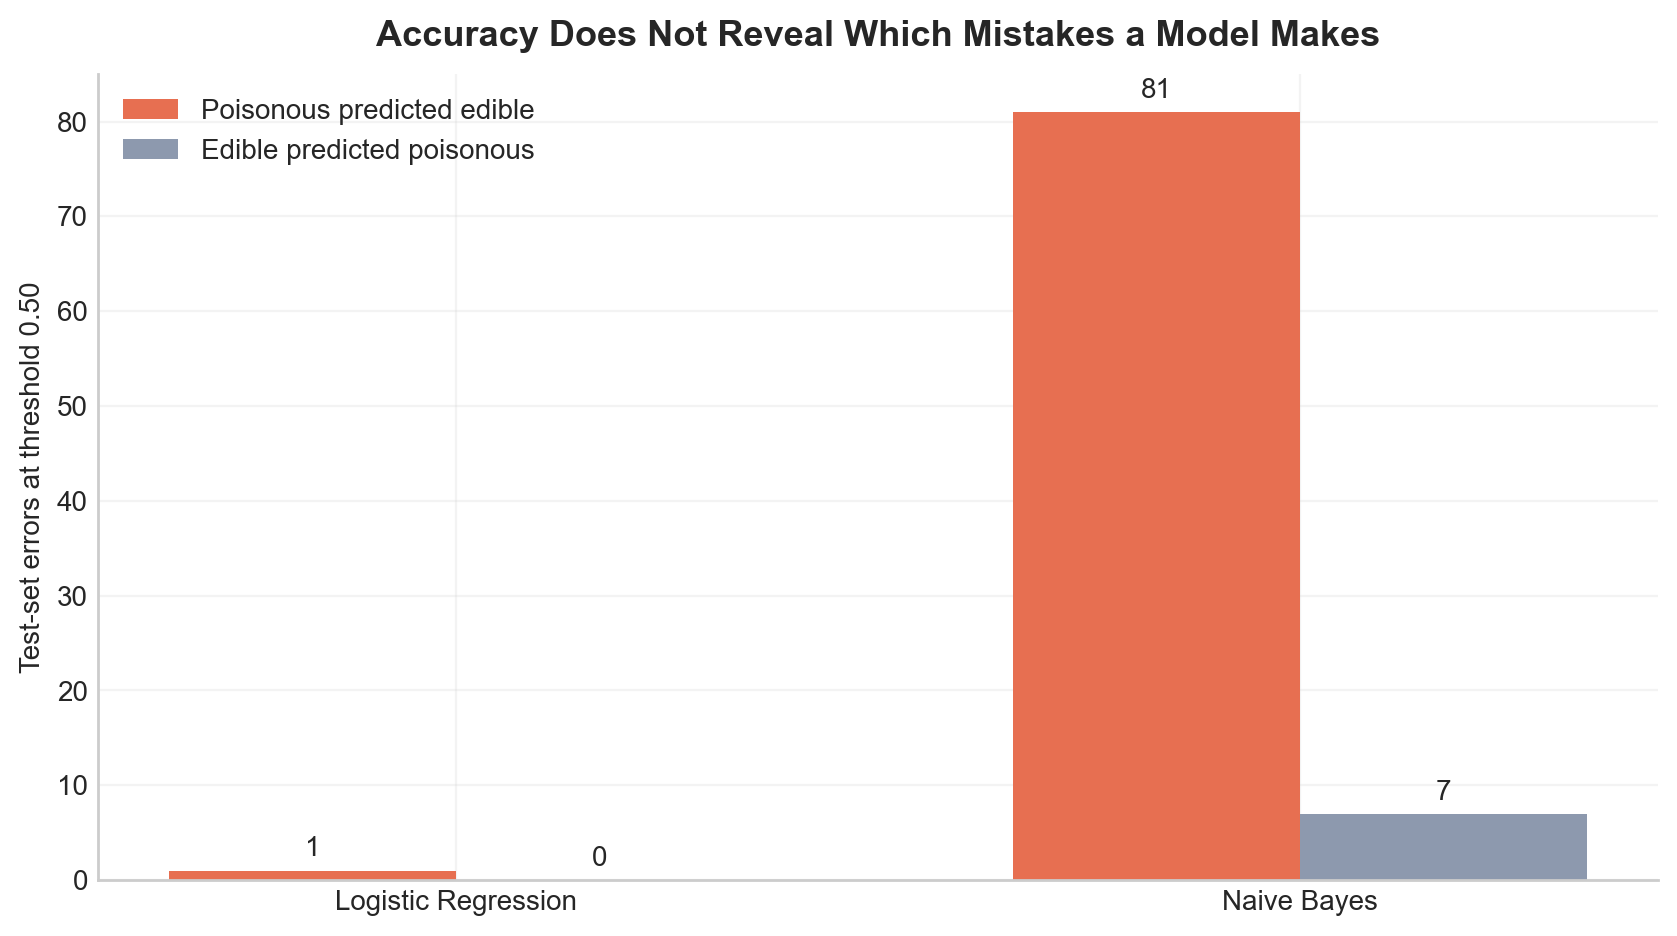

In [25]:
logistic_model = make_pipeline(
    OneHotEncoder(handle_unknown="ignore"),
    LogisticRegression(max_iter=2_000, random_state=42),
)
logistic_model.fit(X_train, y_train)
logistic_probability = logistic_model.predict_proba(X_test)[:, 1]

# CategoricalNB needs nonnegative integer category IDs. Unknown test categories
# receive ID 0; observed training categories begin at ID 1.
nb_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_nb = nb_encoder.fit_transform(X_train).astype(int) + 1
X_test_nb = nb_encoder.transform(X_test).astype(int) + 1
naive_bayes_model = CategoricalNB(alpha=1.0)
naive_bayes_model.fit(X_train_nb, y_train)
naive_bayes_probability = naive_bayes_model.predict_proba(X_test_nb)[:, 1]

probabilities = {
    "Logistic Regression": logistic_probability,
    "Naive Bayes": naive_bayes_probability,
}


def evaluate_probabilities(name, probability):
    prediction = (probability >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, prediction).ravel()
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "False negatives": fn,
        "False positives": fp,
        "Brier score": brier_score_loss(y_test, probability),
        "Log loss": log_loss(y_test, probability),
    }


model_results = pd.DataFrame([
    evaluate_probabilities(name, probability)
    for name, probability in probabilities.items()
])
display(
    model_results.style
    .format({"Accuracy": "{:.1%}", "Brier score": "{:.4f}", "Log loss": "{:.4f}"})
    .hide(axis="index")
)

error_counts = model_results.set_index("Model")[["False negatives", "False positives"]]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x_positions = np.arange(len(error_counts))
width = 0.34
bars_fn = ax.bar(
    x_positions - width / 2,
    error_counts["False negatives"],
    width,
    color=COLORS["poison"],
    label="Poisonous predicted edible",
)
bars_fp = ax.bar(
    x_positions + width / 2,
    error_counts["False positives"],
    width,
    color=COLORS["muted"],
    label="Edible predicted poisonous",
)
ax.bar_label(bars_fn, padding=3)
ax.bar_label(bars_fp, padding=3)
ax.set_xticks(x_positions, error_counts.index)
style_axes(
    ax,
    "Accuracy Does Not Reveal Which Mistakes a Model Makes",
    "",
    "Test-set errors at threshold 0.50",
)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Proper preprocessing changes the story: logistic regression is nearly perfect on this random split, while Naive Bayes makes many more dangerous errors. The point is not that one family always wins; it is that an algorithm comparison is meaningful only when the representation matches each model.

## Part 4: Can We Trust the Probabilities?

Accuracy checks decisions after choosing a threshold. Calibration asks a different question: among predictions near $p$, how often is the outcome actually positive? The reliability curve and score distribution must be read together; a point based on a sparsely populated probability region should not carry the same weight as one supported by many predictions.

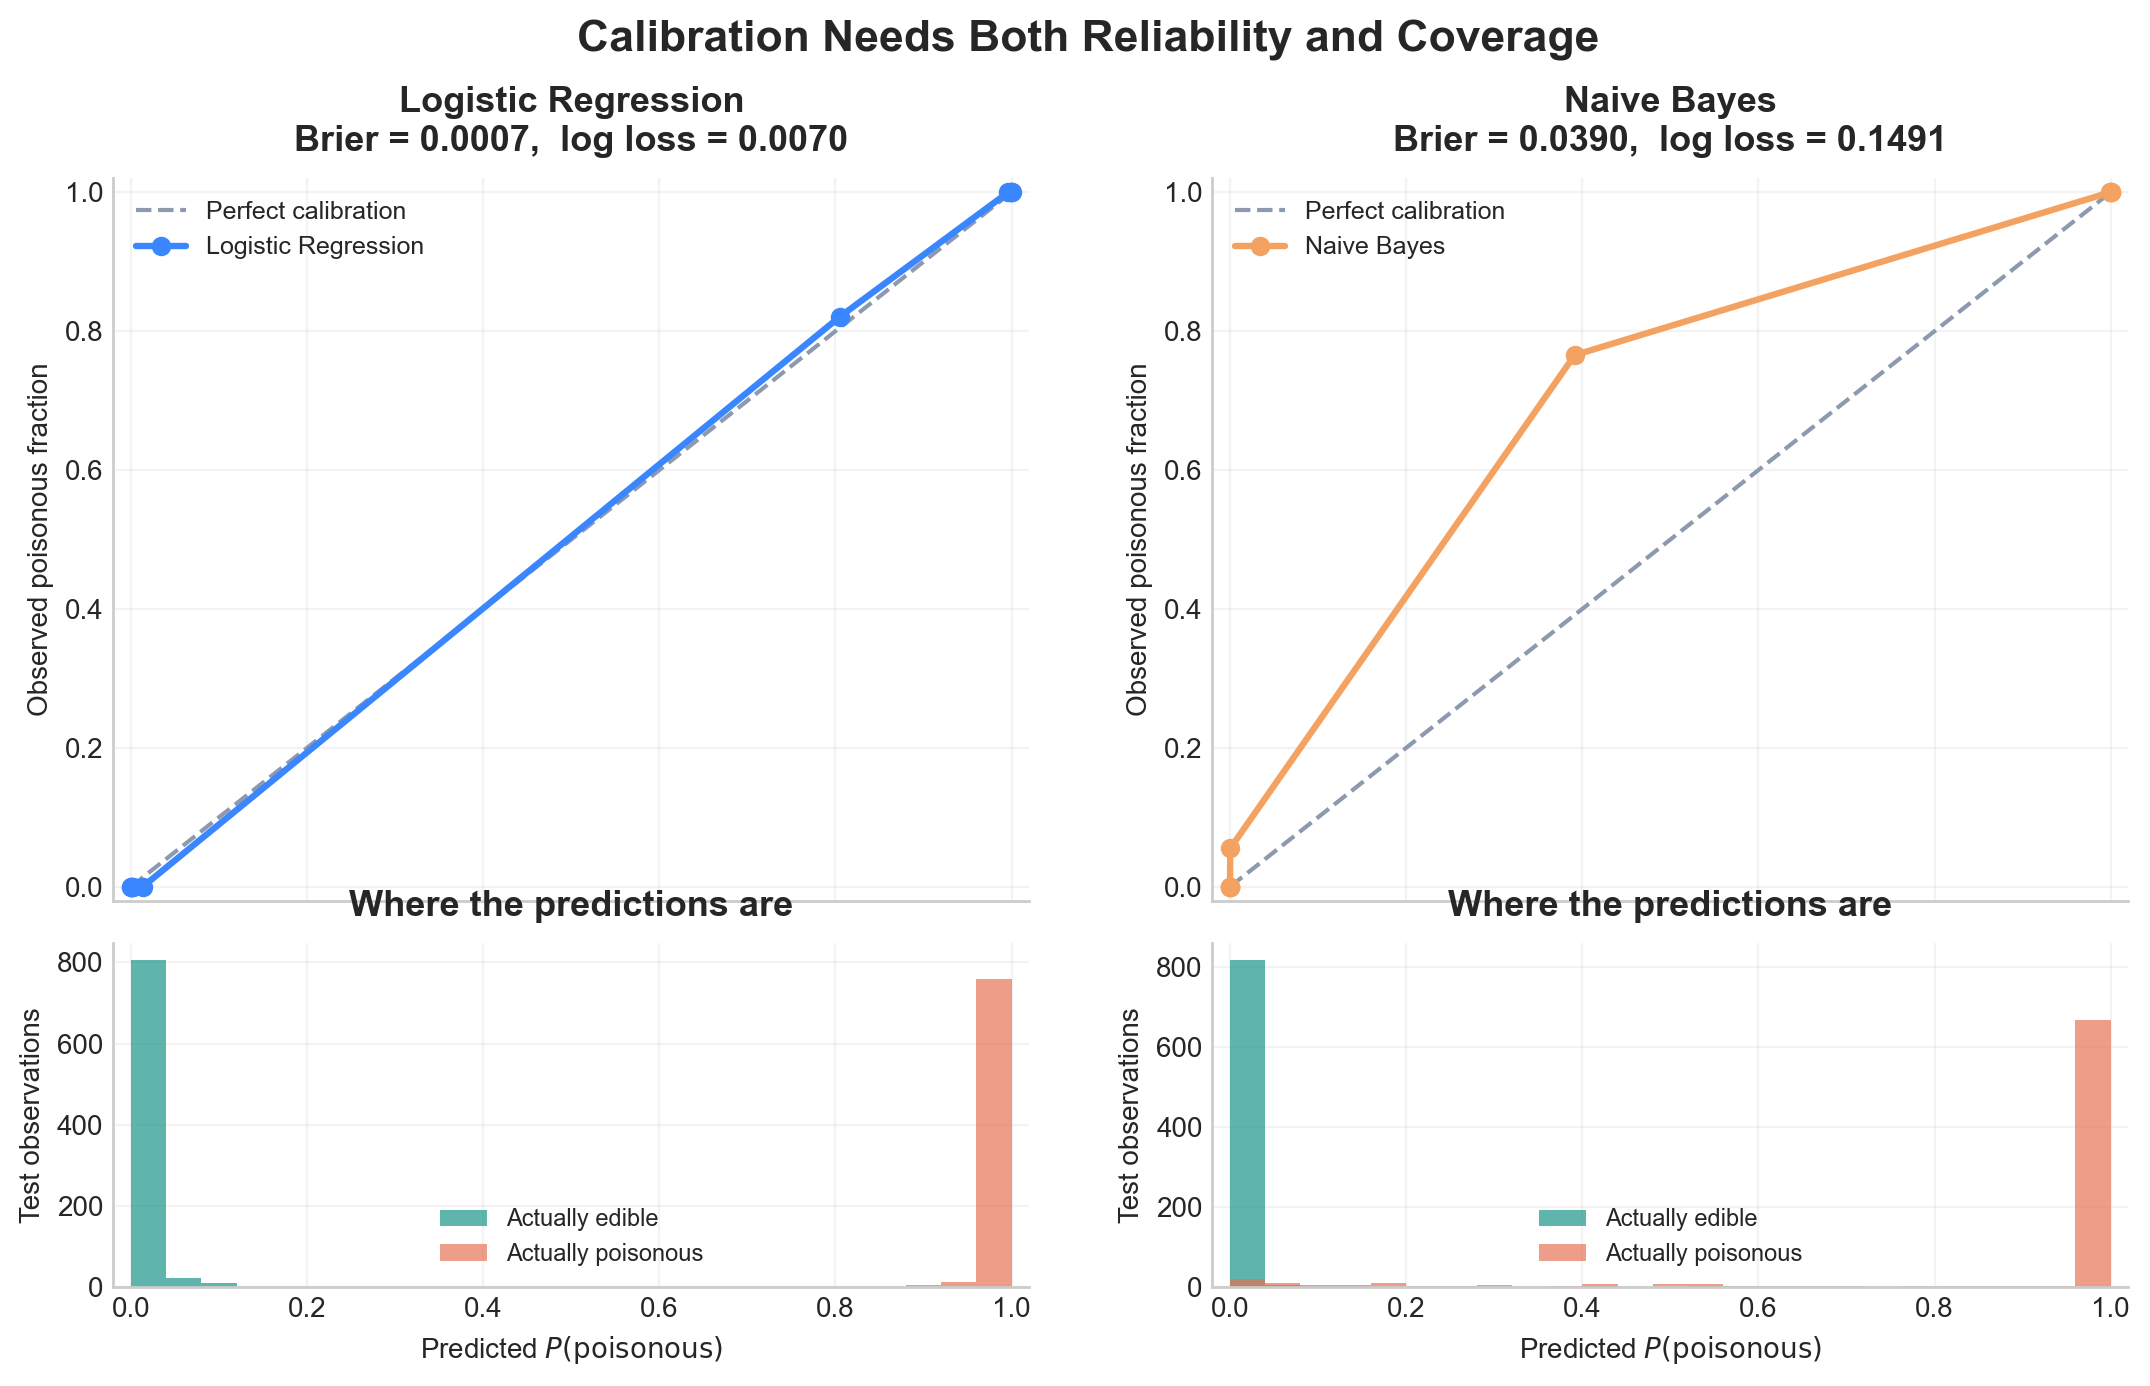

In [26]:
fig = plt.figure(figsize=(13, 7.2))
grid = fig.add_gridspec(2, 2, height_ratios=[2.1, 1], hspace=0.08, wspace=0.20)

for column, (name, probability) in enumerate(probabilities.items()):
    color = COLORS["logistic"] if name == "Logistic Regression" else COLORS["bayes"]
    calibration_ax = fig.add_subplot(grid[0, column])
    histogram_ax = fig.add_subplot(grid[1, column], sharex=calibration_ax)

    observed_rate, predicted_rate = calibration_curve(
        y_test, probability, n_bins=10, strategy="quantile"
    )
    calibration_ax.plot([0, 1], [0, 1], color=COLORS["muted"],
                        linestyle="--", linewidth=1.5, label="Perfect calibration")
    calibration_ax.plot(predicted_rate, observed_rate, color=color,
                        marker="o", markersize=6, linewidth=2.3, label=name)
    calibration_ax.set_xlim(-0.02, 1.02)
    calibration_ax.set_ylim(-0.02, 1.02)
    style_axes(
        calibration_ax,
        f"{name}\nBrier = {brier_score_loss(y_test, probability):.4f},  "
        f"log loss = {log_loss(y_test, probability):.4f}",
        "",
        "Observed poisonous fraction",
    )
    calibration_ax.legend(frameon=False, fontsize=9, loc="upper left")
    calibration_ax.tick_params(axis="x", labelbottom=False)

    bins = np.linspace(0, 1, 26)
    histogram_ax.hist(probability[y_test.to_numpy() == 0], bins=bins,
                      color=COLORS["edible"], alpha=0.75, label="Actually edible")
    histogram_ax.hist(probability[y_test.to_numpy() == 1], bins=bins,
                      color=COLORS["poison"], alpha=0.68, label="Actually poisonous")
    style_axes(
        histogram_ax,
        "Where the predictions are",
        r"Predicted $P(\mathrm{poisonous})$",
        "Test observations",
    )
    histogram_ax.legend(frameon=False, fontsize=8.5)

fig.suptitle("Calibration Needs Both Reliability and Coverage",
             fontsize=16, fontweight="bold", y=0.99)
plt.show()

Logistic regression has much better probability scores on this split. Still, most of its predictions are near 0 or 1, so the notebook has little evidence about how trustworthy a claim such as “60% poisonous” would be. Calibration on one random split is an audit of this experiment—not certification for new species, regions, or measurement processes.

## Part 5 (Advanced): Where the Models Tell Different Stories

Calibration audits each model across many records. Disagreement offers a complementary, case-level diagnostic: it identifies inputs for which different assumptions produce sharply different probabilities. Disagreement does not tell us which model is right, but it tells us where closer inspection may be worthwhile.

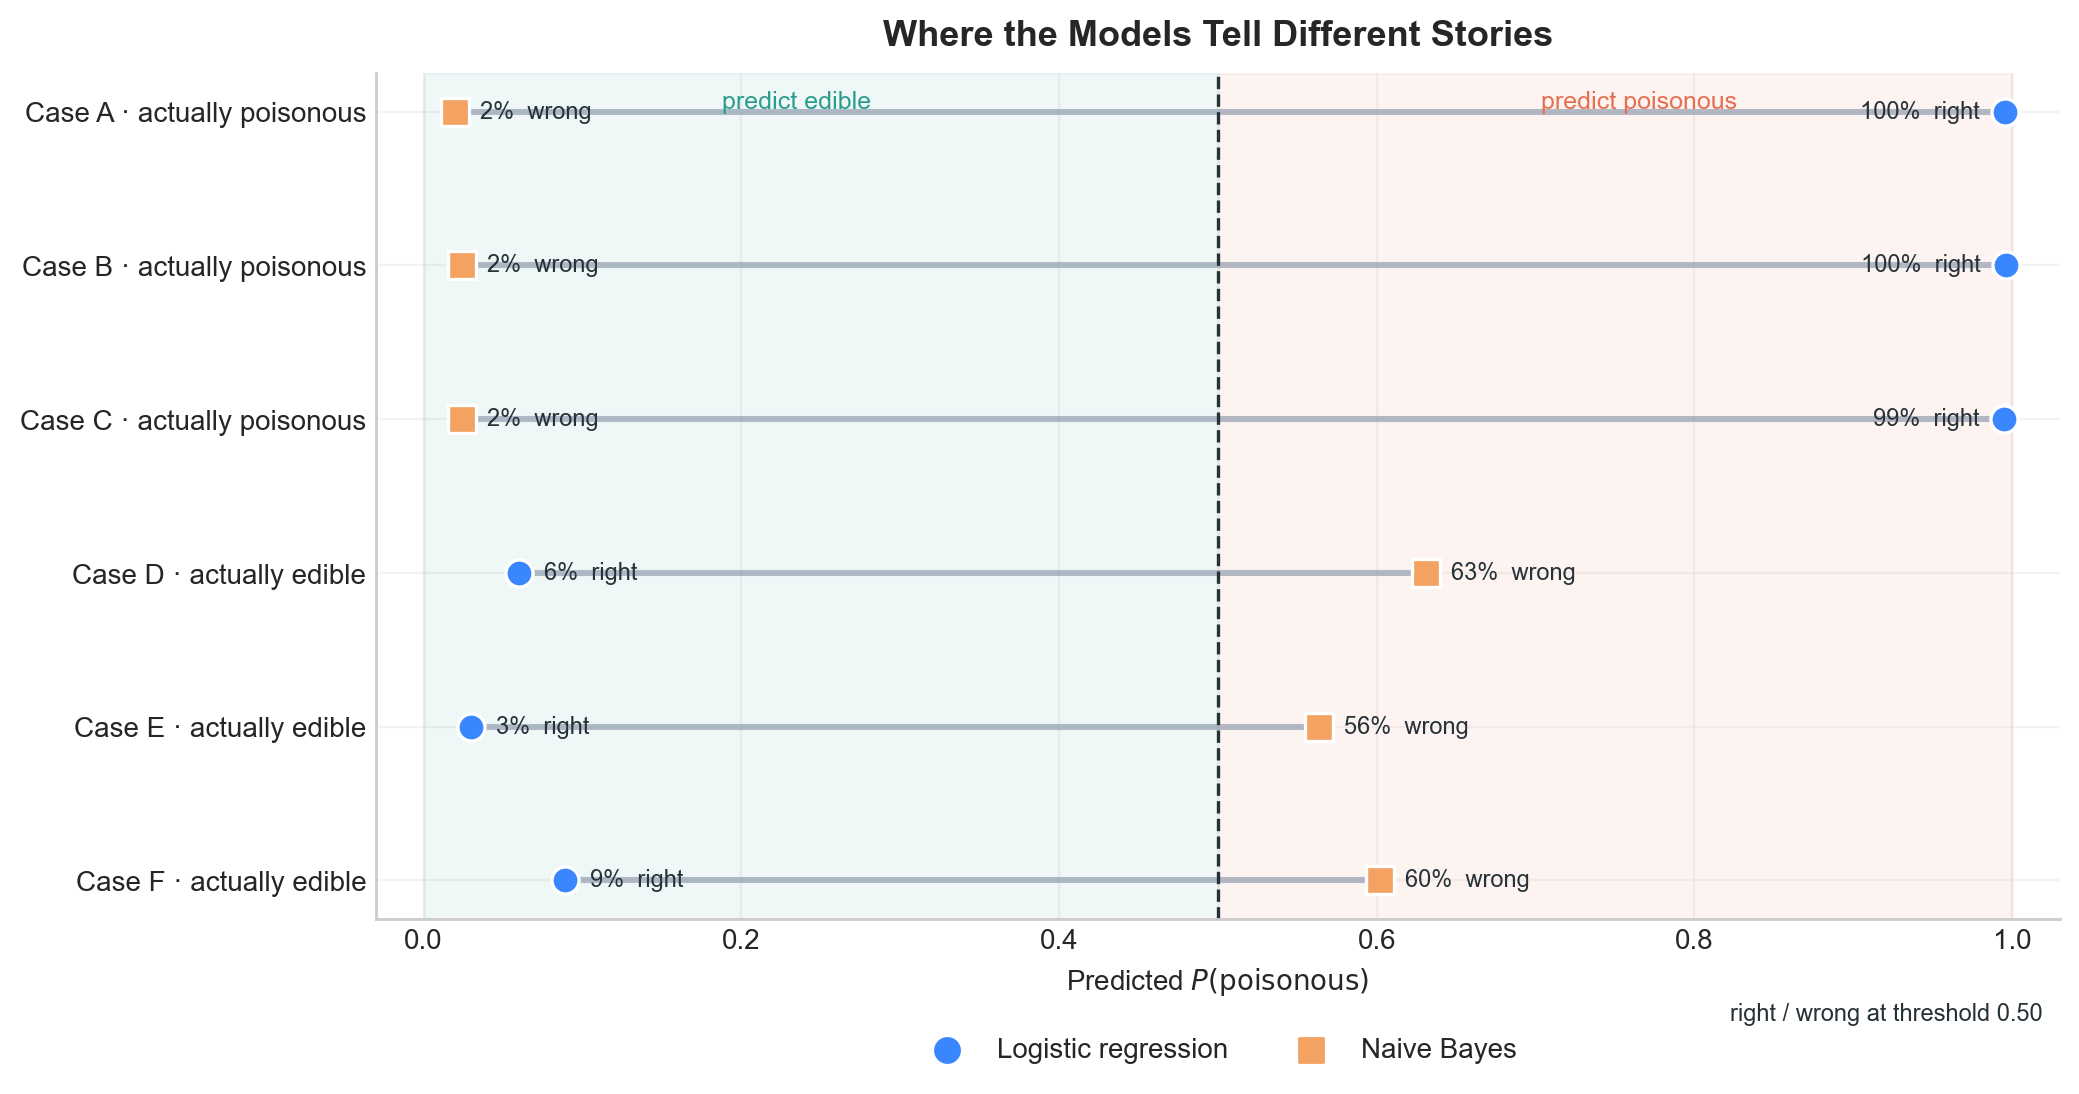

In [27]:
# Keep the strongest disagreements from both true classes so one pattern
# does not crowd every other case out of the picture.
disagreement_cases = pd.DataFrame({
    "position": np.arange(len(y_test)),
    "truth": y_test.to_numpy(),
    "logistic": logistic_probability,
    "naive bayes": naive_bayes_probability,
})
disagreement_cases["gap"] = np.abs(
    disagreement_cases["logistic"] - disagreement_cases["naive bayes"]
)
disagreement_cases = disagreement_cases[
    (disagreement_cases["logistic"] >= 0.5)
    != (disagreement_cases["naive bayes"] >= 0.5)
]
display_cases = (
    disagreement_cases.sort_values("gap", ascending=False)
    .groupby("truth", group_keys=False)
    .head(3)
    .sort_values("gap", ascending=False)
    .reset_index(drop=True)
)
display_cases["case"] = list("ABCDEF")

fig, ax = plt.subplots(figsize=(10.5, 5.6))
ax.axvspan(0, 0.5, color=COLORS["edible"], alpha=0.07)
ax.axvspan(0.5, 1, color=COLORS["poison"], alpha=0.07)
ax.axvline(0.5, color=COLORS["ink"], linestyle="--", linewidth=1.2)

for row_number, row in display_cases.iterrows():
    probabilities_for_case = [row["logistic"], row["naive bayes"]]
    ax.plot(probabilities_for_case, [row_number, row_number],
            color=COLORS["muted"], linewidth=2.2, alpha=0.65, zorder=1)
    for model_name, marker, color in [
        ("logistic", "o", COLORS["logistic"]),
        ("naive bayes", "s", COLORS["bayes"]),
    ]:
        probability_value = row[model_name]
        is_correct = (probability_value >= 0.5) == bool(row["truth"])
        horizontal_offset = -9 if probability_value > 0.82 else 9
        ax.scatter(probability_value, row_number, s=95, marker=marker,
                   color=color, edgecolor="white", linewidth=1.2, zorder=3)
        ax.annotate(
            f"{probability_value:.0%}  {'right' if is_correct else 'wrong'}",
            (probability_value, row_number),
            xytext=(horizontal_offset, 0),
            textcoords="offset points",
            ha="right" if horizontal_offset < 0 else "left",
            va="center",
            fontsize=8.5,
            color=COLORS["ink"],
        )

truth_labels = [
    f"Case {row['case']} · actually {'poisonous' if row['truth'] else 'edible'}"
    for _, row in display_cases.iterrows()
]
ax.set_yticks(np.arange(len(display_cases)), truth_labels)
ax.invert_yaxis()
ax.set_xlim(-0.03, 1.03)
ax.scatter([], [], s=75, marker="o", color=COLORS["logistic"],
           label="Logistic regression")
ax.scatter([], [], s=75, marker="s", color=COLORS["bayes"],
           label="Naive Bayes")
style_axes(
    ax,
    "Where the Models Tell Different Stories",
    r"Predicted $P(\mathrm{poisonous})$",
    "",
)
ax.text(0.25, 0.98, "predict edible", transform=ax.transAxes,
        ha="center", va="top", fontsize=9, color=COLORS["edible"])
ax.text(0.75, 0.98, "predict poisonous", transform=ax.transAxes,
        ha="center", va="top", fontsize=9, color=COLORS["poison"])
ax.text(0.99, -0.12, "right / wrong at threshold 0.50",
        transform=ax.transAxes, ha="right", fontsize=8.5, color=COLORS["ink"])
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.20), ncol=2)
plt.tight_layout()
plt.show()

# Use the largest displayed disagreement for the evidence audit below.
test_position = int(display_cases.loc[0, "position"])

> **Beyond labeled test data: disagreement without labels.** Here the labels let us see which model is right. In deployment, shifted data may arrive without labels. [Baek et al. (2022), *Agreement-on-the-Line*](https://papers.nips.cc/paper_files/paper/2022/hash/7a8d388b7a17df480856dff1cc079b08-Abstract-Conference.html), found that agreement among collections of neural networks can track accuracy under several distribution shifts. This two-model example is only a small-scale intuition: disagreement is a reason to investigate, not proof that a record is out of distribution or that either model is wrong.

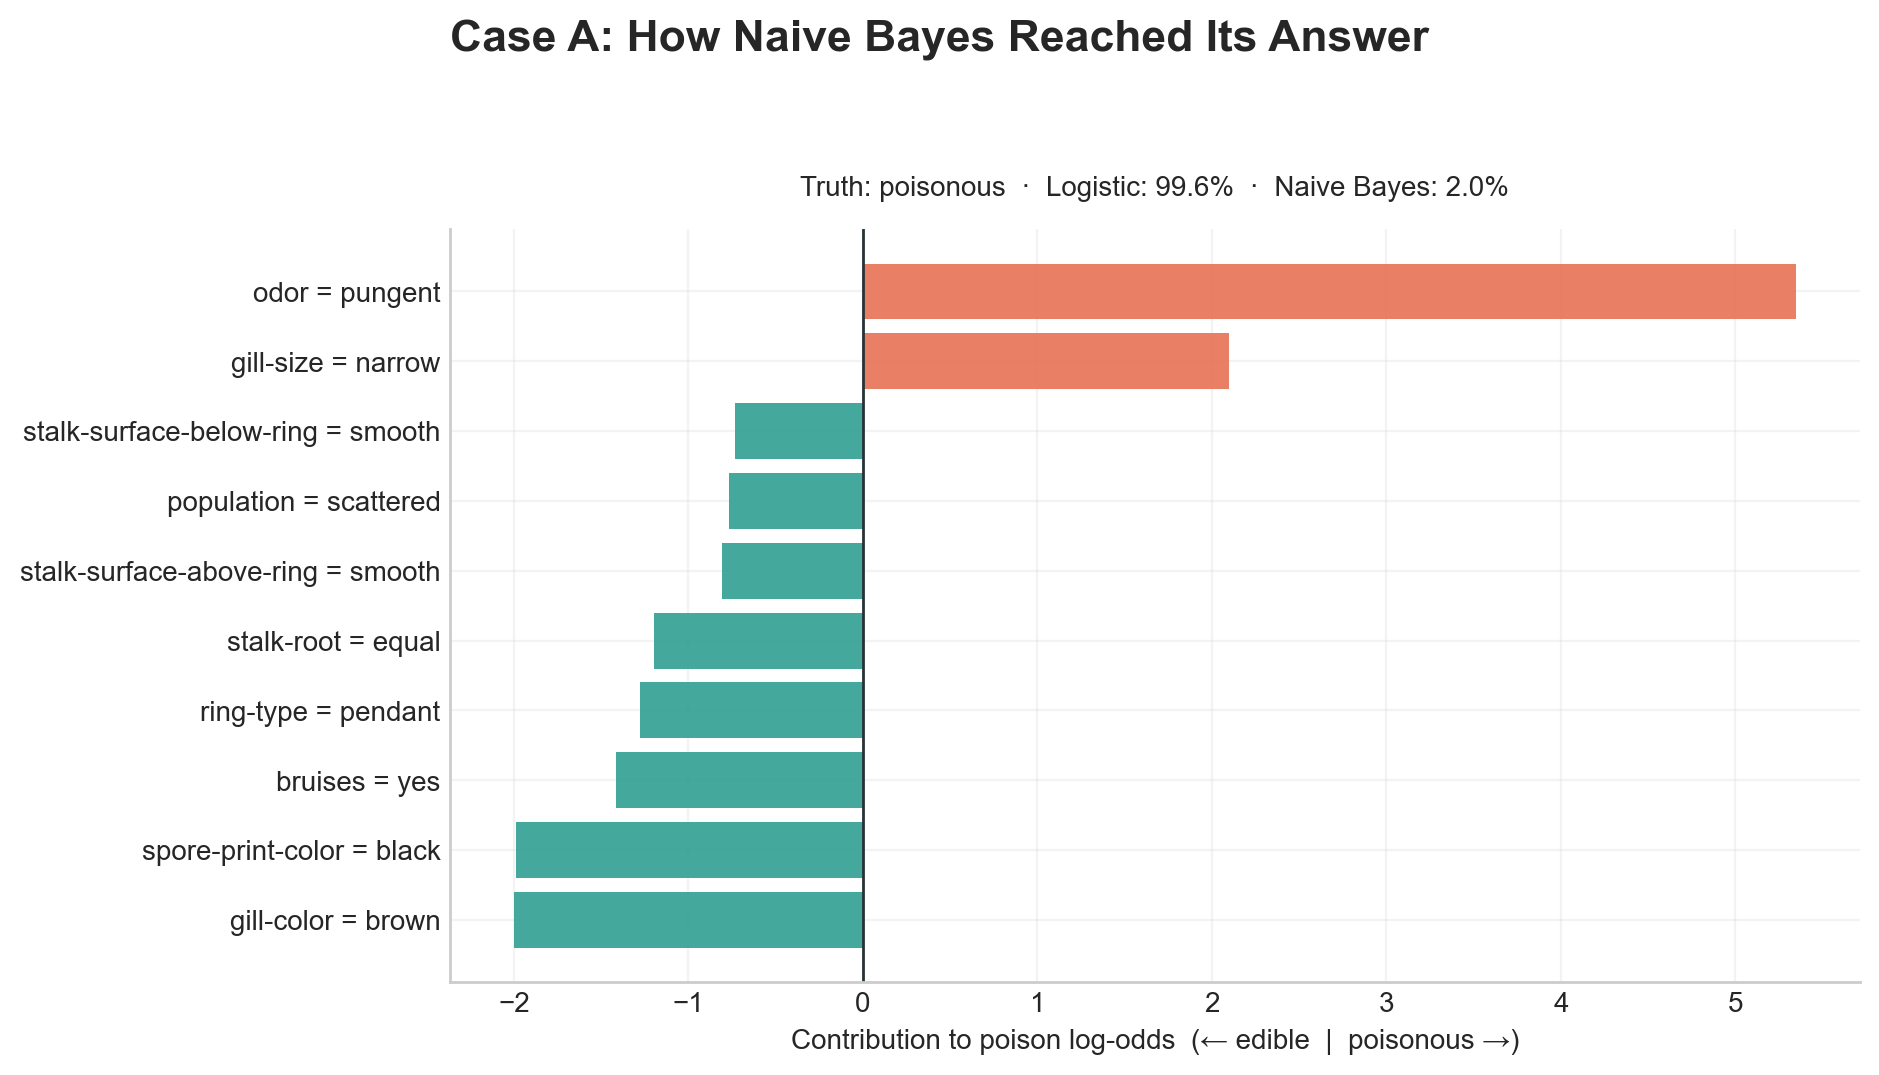

In [28]:
# Audit how Naive Bayes combined the clues for Case A.
evidence_rows = []
encoded_sample = X_test_nb[test_position]
for feature_index, (feature, category_id) in enumerate(zip(FEATURES, encoded_sample)):
    contribution = (
        naive_bayes_model.feature_log_prob_[feature_index][1, category_id]
        - naive_bayes_model.feature_log_prob_[feature_index][0, category_id]
    )
    evidence_rows.append({
        "feature": feature,
        "value": X_test.iloc[test_position][feature],
        "contribution": contribution,
    })
evidence = pd.DataFrame(evidence_rows)
evidence["magnitude"] = evidence["contribution"].abs()
largest_evidence = evidence.nlargest(10, "magnitude").sort_values("contribution")
largest_evidence["label"] = largest_evidence.apply(
    lambda row: (
        f"{row['feature']} = "
        f"{CATEGORY_NAMES.get(row['feature'], {}).get(row['value'], row['value'])}"
    ),
    axis=1,
)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
evidence_colors = np.where(
    largest_evidence["contribution"] > 0,
    COLORS["poison"],
    COLORS["edible"],
)
ax.barh(
    largest_evidence["label"],
    largest_evidence["contribution"],
    color=evidence_colors,
    alpha=0.88,
)
ax.axvline(0, color=COLORS["ink"], linewidth=1)
style_axes(
    ax,
    "",
    "Contribution to poison log-odds  (← edible  |  poisonous →)",
)
ax.set_title(
    (
        f"Truth: poisonous  ·  Logistic: {logistic_probability[test_position]:.1%}  ·  "
        f"Naive Bayes: {naive_bayes_probability[test_position]:.1%}"
    ),
    fontsize=10,
    pad=12,
)
fig.suptitle("Case A: How Naive Bayes Reached Its Answer",
             fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

The evidence audit shows how Naive Bayes assembled its answer for one record; it does not prove that conditional dependence caused this particular error. Treat disagreement as a prompt to inspect assumptions and evidence, not as a diagnosis by itself.

## Part 6: A Probability Is Not Yet a Decision

The threshold converts a probability into an action. Lowering it labels more mushrooms as poisonous: the poisonous-miss rate should fall while the edible-rejection rate rises. Those quantities share one scale below; the raw counts remain visible in the labels.

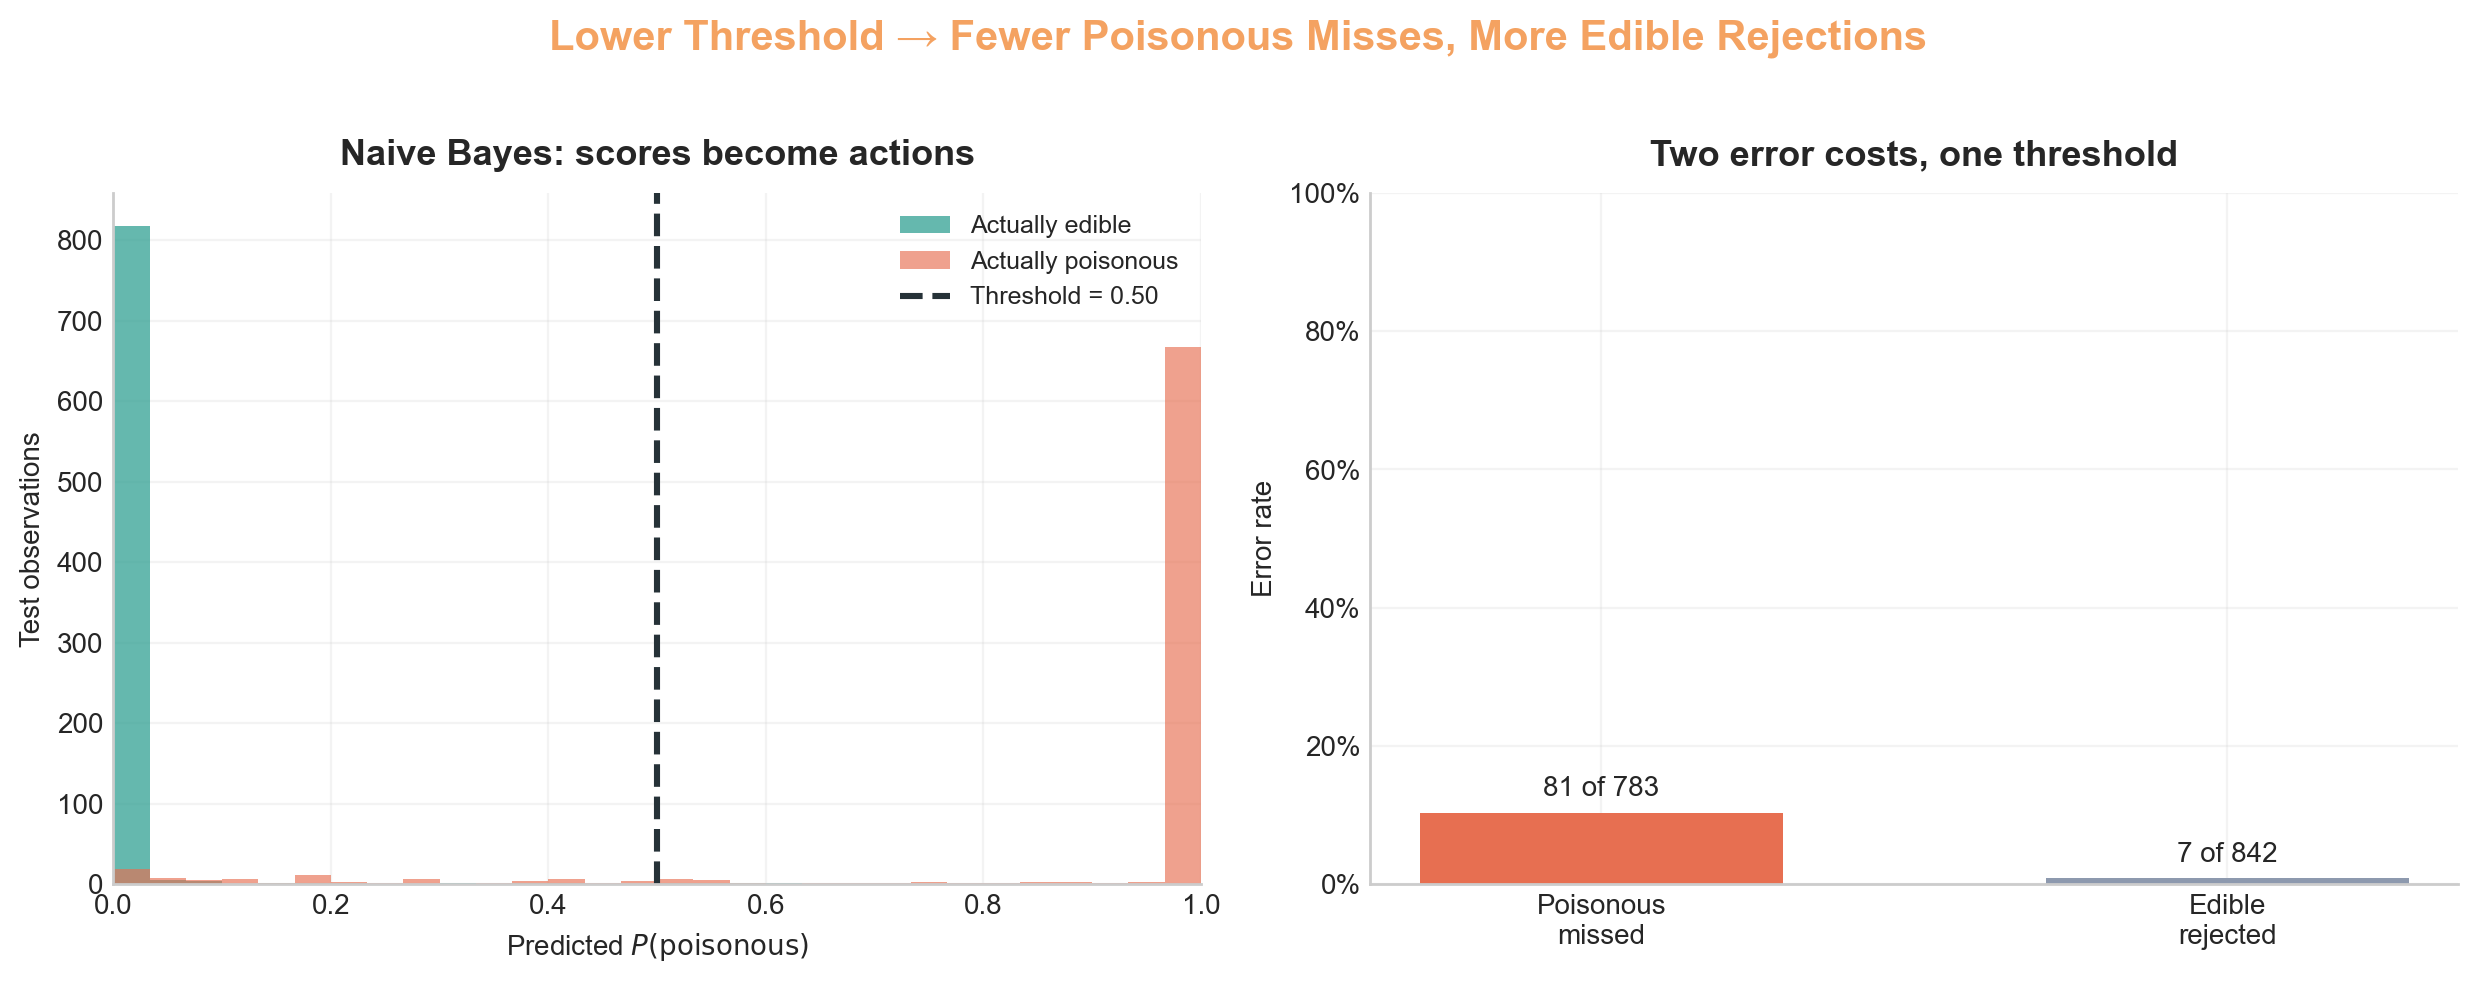

interactive(children=(ToggleButtons(description='Model:', index=1, options=('Logistic Regression', 'Naive Baye…

In [29]:
def threshold_explorer(model, threshold):
    probability = probabilities[model]
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, prediction).ravel()
    poison_total = fn + tp
    edible_total = tn + fp
    error_rates = [fn / poison_total, fp / edible_total]
    model_color = COLORS["logistic"] if model == "Logistic Regression" else COLORS["bayes"]

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
    bins = np.linspace(0, 1, 31)
    axes[0].hist(probability[y_test.to_numpy() == 0], bins=bins,
                 color=COLORS["edible"], alpha=0.72, label="Actually edible")
    axes[0].hist(probability[y_test.to_numpy() == 1], bins=bins,
                 color=COLORS["poison"], alpha=0.65, label="Actually poisonous")
    axes[0].axvline(threshold, color=COLORS["ink"], linewidth=2.2,
                    linestyle="--", label=f"Threshold = {threshold:.2f}")
    style_axes(
        axes[0],
        f"{model}: scores become actions",
        r"Predicted $P(\mathrm{poisonous})$",
        "Test observations",
    )
    axes[0].set_xlim(0, 1)
    axes[0].legend(frameon=False, fontsize=9)

    bars = axes[1].bar(
        ["Poisonous\nmissed", "Edible\nrejected"],
        error_rates,
        color=[COLORS["poison"], COLORS["muted"]],
        width=0.58,
    )
    labels = [f"{fn} of {poison_total}", f"{fp} of {edible_total}"]
    axes[1].bar_label(bars, labels=labels, padding=4, fontsize=10)
    style_axes(
        axes[1],
        "Two error costs, one threshold",
        "",
        "Error rate",
    )
    axes[1].set_ylim(0, 1.0)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

    fig.suptitle(
        "Lower Threshold → Fewer Poisonous Misses, More Edible Rejections",
        fontsize=15,
        fontweight="bold",
        y=1.02,
        color=model_color,
    )
    plt.tight_layout()
    plt.show()


# Keep a useful default view in static notebook renderers such as GitHub.
threshold_explorer("Naive Bayes", 0.50)

_ = widgets.interact(
    threshold_explorer,
    model=widgets.ToggleButtons(
        options=list(probabilities),
        value="Naive Bayes",
        description="Model:",
    ),
    threshold=widgets.FloatSlider(
        value=0.50,
        min=0.01,
        max=0.99,
        step=0.01,
        description="Poison threshold:",
        style={"description_width": "initial"},
        continuous_update=False,
    ),
)

## Wrap-Up

Probabilistic classification separates three questions that accuracy alone collapses: how evidence becomes a probability, whether that probability deserves trust, and what action its value should trigger. Logistic regression learns the class probability directly from a weighted score, while Naive Bayes builds it from priors and feature likelihoods; the latter can be remarkably effective, but correlated evidence can be counted repeatedly and produce brittle confidence. Cross-entropy rewards probability estimates that assign high mass to what occurs, calibration checks those estimates against observed frequencies, and the decision threshold finally encodes the asymmetric costs of false positives and false negatives. A responsible classifier therefore requires a suitable representation, an honest probability audit, and a threshold chosen for the consequences—not a default inherited from the software.

**Data:** UCI Mushroom Database (1987), included locally in this repository. The records are hypothetical field-guide samples and are used here only for teaching.